### Recurrent Neural Network (LSTM, V2)

This is a basic convolutional approach to sequence prediction using convolutions through TensorFlow!

We begin by important any relevant packages, modules, and the DataProcessor class (for our pre-processed data). Then we get our dataset ready.

In [26]:
from tensorflow.keras import backend as K
K.clear_session()

In [27]:
import os, sys
sys.path.append(os.path.abspath('..'))  # add parent directory to sys.path
from data_cleanup import DataProcessor
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Define the windowing parameters
# Use 24 hours of history
INPUT_WINDOW = 24  
# Predict the next 24 hours
OUTPUT_WINDOW = 24 

# Initialize the class
processor = DataProcessor(input_steps=INPUT_WINDOW, output_steps=OUTPUT_WINDOW)

# Run the pipeline
(X_train, y_train), (X_val, y_val), (X_test, y_test) = processor.load_and_process_data()

# Check the final shapes
print("\n--- Final Data Shapes ---")
print(f"X_train shape: {X_train.shape}  | y_train shape: {y_train.shape}")
print(f"X_val shape:   {X_val.shape}     | y_val shape:   {y_val.shape}")
print(f"X_test shape:  {X_test.shape}    | y_test shape:  {y_test.shape}")

Step 1/5: Fetching, cleaning, and engineering features...


/Users/ferhawnshaheen/.pyenv/versions/3.12.7/lib/python3.12/site-packages/ucimlrepo/fetch.py:97: DtypeWarning: Columns (2,3,4,5,6,7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_url)
/Users/ferhawnshaheen/github/ECS171G13/data_cleanup.py:132: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/Users/ferhawnshaheen/github/ECS171G13/data_cleanup.py:172: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df.resample('H').agg(agg_dict)


Step 2/5: Resampling data to hourly and setting 'Global_active_power' as target...
Step 3/5: Splitting data and applying scaler...
Step 4/5: Creating time-series windows...
Step 5/5: Data processing complete.

--- Final Data Shapes ---
X_train shape: (25880, 24, 8)  | y_train shape: (25880, 24)
X_val shape:   (3577, 24, 8)     | y_val shape:   (3577, 24)
X_test shape:  (4991, 24, 8)    | y_test shape:  (4991, 24)


/Users/ferhawnshaheen/github/ECS171G13/data_cleanup.py:173: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_hourly = df_hourly.fillna(method='ffill')


Next, we want to build the model itself. Keras makes this very simple at a high-level, so tuning is also easy to do.

In [28]:
# Initialize the "order" of layers to be inserted. Will be a simple sequence.
model = Sequential()

# Add the first layer, which is an LSTM layer. We will choose to have 64 neurons, which sets the dimensionality seen
# throughout the LSTM layer.   
model.add(LSTM(units=64, return_sequences=True, input_shape=(24, 8)))

# Add a dropout layer to set some neurons to 0 for regularization. This prevents overfitting
model.add(Dropout(0.2))

# Add another LSTM layer but with 32 neurons.
model.add(LSTM(32))

# Add another dropout layer.
model.add(Dropout(0.2))

# The second layer is the final layer. This is a Dense one so we get 24 hours to predict.
model.add(Dense(OUTPUT_WINDOW))

# Set some parameters for how model will be optimized and how loss is calculated.
model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])

/Users/ferhawnshaheen/.pyenv/versions/3.12.7/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Now we want to fit the model, train it, and determine an error metric.

In [29]:
# Early stopping to prevent overfitting
es = EarlyStopping(patience=5, restore_best_weights=True)

# Create a checkpoints directory and define the checkpoint path
os.makedirs('checkpoints', exist_ok=True)
checkpoint_path = os.path.join('checkpoints', 'lstm_v2.keras')
mc = ModelCheckpoint(
    filepath=checkpoint_path,
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1,
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,          
    batch_size=64,
    callbacks=[es, mc],
    verbose=1
)

print("Training complete.")
print(f"Best model checkpoint saved to: {checkpoint_path}")

print("Making predictions on the test set...")
predictions_scaled = model.predict(X_test)

# If the data is 3D (e.g., [Rows, 24, 1]), squeeze it to 2D (e.g., [Rows, 24])
if predictions_scaled.ndim == 3:
    predictions_scaled = np.squeeze(predictions_scaled)
    
if y_test.ndim == 3:
    y_test = np.squeeze(y_test)

mse_scaled = mean_squared_error(y_test, predictions_scaled)
rmse_scaled = np.sqrt(mse_scaled)

print(f'\n--- Model Evaluation ---')
print(f'Test Set MSE (Mean Squared Error): {mse_scaled:.4f}')

# This is the human-readable version 
print(f'Test Set RMSE (Root Mean Squared Error): {rmse_scaled:.4f}')
print(f'(This means, on average, the model was off by approx. {rmse_scaled:.2f} kilowatts)')

total_params = model.count_params()
print(f'\n--- Model Architecture Stats ---')
print(f'Total Trainable Parameters: {total_params}')

Epoch 1/20
400/405 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0220 - mae: 0.1115
Epoch 1: val_loss improved from None to 0.01438, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 0.0189 - mae: 0.1045 - val_loss: 0.0144 - val_mae: 0.0924
Epoch 2/20
401/405 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0153 - mae: 0.0920
Epoch 2: val_loss improved from 0.01438 to 0.01311, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0149 - mae: 0.0906 - val_loss: 0.0131 - val_mae: 0.0879
Epoch 3/20
401/405 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0142 - mae: 0.0885
Epoch 3: val_loss did not improve from 0.01311
405/405 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0141 - mae: 0.0881 - val_loss: 0.0132 - val_mae: 0.0873
Epoch 4/20
403/405 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0138 - mae: 0.0870
Epoch 4: val_loss improved from 0.01311 to 0.01299, saving model to checkpoints/lstm_v2.keras
405/405 ━━━━━━━━━━━━━━━━━━━━ 

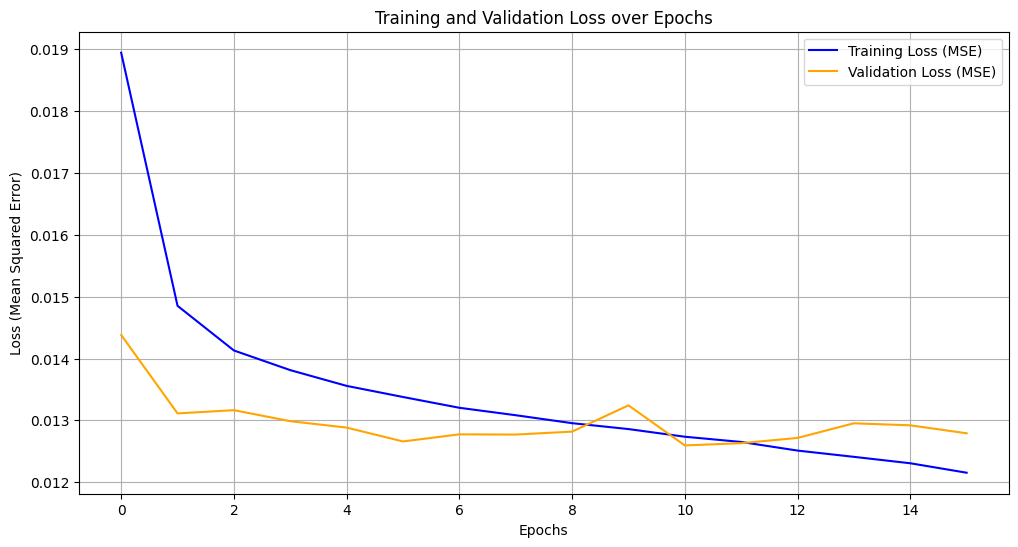

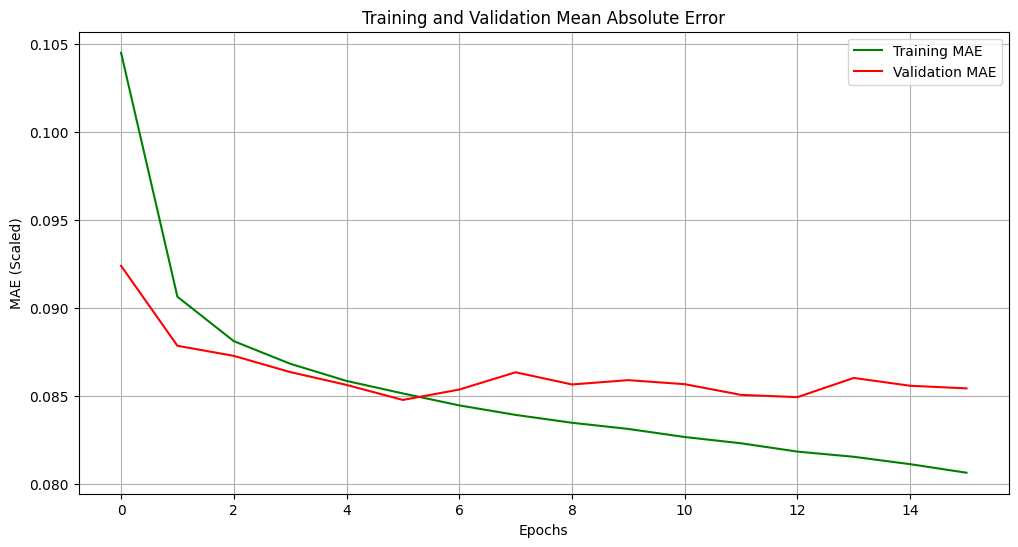

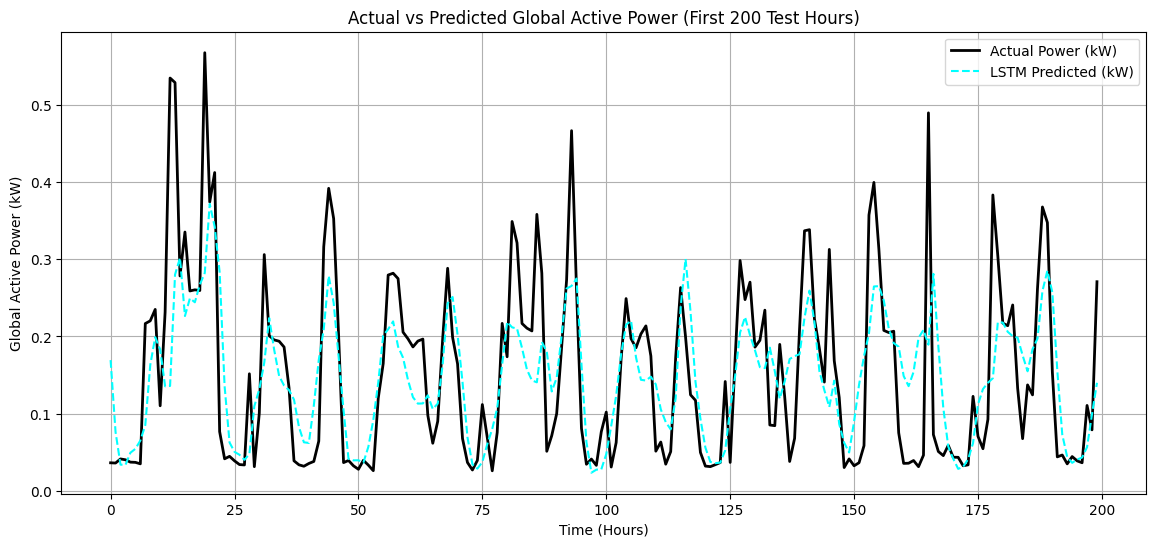

In [30]:
# Graph 1: Loss Curves (MSE)

plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss (MSE)', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)', color='orange')
plt.title('Training and Validation Loss over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 2: MAE Curves

plt.figure(figsize=(12, 6))
plt.plot(history.history['mae'], label='Training MAE', color='green')
plt.plot(history.history['val_mae'], label='Validation MAE', color='red')
plt.title('Training and Validation Mean Absolute Error')
plt.xlabel('Epochs')
plt.ylabel('MAE (Scaled)')
plt.legend()
plt.grid(True)
plt.show()

# Graph 3: Actual vs Predicted (Time Series)

# Since the model predicts 24 hours at a time, plotting all of them creates a messy web. 
# Instead, the standard way to plot a clean line is to take the first hour of every prediction window.

# We take the first 200 hours for a clean zoom-in (like the uploaded image)
subset_n = 200 

# Extract just the 1st hour prediction from each window (index 0)
# This reconstructs a continuous timeline
actual_trace = y_test[:subset_n, 0]
pred_trace = predictions_scaled[:subset_n, 0]

plt.figure(figsize=(14, 6))
plt.plot(actual_trace, label='Actual Power (kW)', color='black', linewidth=2)
plt.plot(pred_trace, label='LSTM Predicted (kW)', color='cyan', linestyle='--')
plt.title(f'Actual vs Predicted Global Active Power (First {subset_n} Test Hours)')
plt.xlabel('Time (Hours)')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True)
plt.show()

In [31]:
# Cross Validation for overfitting

#Define CV folds
FOLDS = 3
tscv = TimeSeriesSplit(n_splits=FOLDS)

cv_mse_scores = []
cv_rmse_scores = []

fold = 1
for train_idx, val_idx in tscv.split(X_train):

    print(f"\n----- Fold {fold} -----")

    # Split data respecting time ordering
    X_tr, X_val_cv = X_train[train_idx], X_train[val_idx]
    y_tr, y_val_cv = y_train[train_idx], y_train[val_idx]

    # Build model fresh each fold
    model = Sequential()
    model.add(LSTM(64, return_sequences=True, input_shape=(24, 8)))
    model.add(Dropout(0.2))
    model.add(LSTM(32))
    model.add(Dropout(0.2))
    model.add(Dense(OUTPUT_WINDOW))

    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    es = EarlyStopping(patience=5, restore_best_weights=True)

    history = model.fit(
        X_tr, y_tr,
        validation_data=(X_val_cv, y_val_cv),
        epochs=20,
        batch_size=64,
        callbacks=[es],
        verbose=1
    )

    # Predict on this fold's validation set
    val_pred = model.predict(X_val_cv)
    
    if val_pred.ndim == 3:
        val_pred = np.squeeze(val_pred)
    if y_val_cv.ndim == 3:
        y_val_cv = np.squeeze(y_val_cv)

    # Compute metrics
    mse = mean_squared_error(y_val_cv, val_pred)
    rmse = np.sqrt(mse)

    cv_mse_scores.append(mse)
    cv_rmse_scores.append(rmse)

    print(f"Fold {fold} MSE:  {mse:.4f}")
    print(f"Fold {fold} RMSE: {rmse:.4f}")

    fold += 1


print("\nCross-Validation Summary")
print(f"Average MSE:  {np.mean(cv_mse_scores):.4f}")
print(f"Average RMSE: {np.mean(cv_rmse_scores):.4f}")


----- Fold 1 -----
Epoch 1/20


/Users/ferhawnshaheen/.pyenv/versions/3.12.7/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


102/102 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 0.0246 - mae: 0.1190 - val_loss: 0.0230 - val_mae: 0.1185
Epoch 2/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0212 - mae: 0.1130 - val_loss: 0.0215 - val_mae: 0.1163
Epoch 3/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0198 - mae: 0.1086 - val_loss: 0.0198 - val_mae: 0.1089
Epoch 4/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0181 - mae: 0.1020 - val_loss: 0.0181 - val_mae: 0.1013
Epoch 5/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0169 - mae: 0.0980 - val_loss: 0.0177 - val_mae: 0.0986
Epoch 6/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0164 - mae: 0.0963 - val_loss: 0.0177 - val_mae: 0.1013
Epoch 7/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0161 - mae: 0.0952 - val_loss: 0.0176 - val_mae: 0.0986
Epoch 8/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0159 - mae: 0.0943 - val_loss: 0.0176 - val_mae: 0.1023
Epoch 9/20
102/102 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss

/Users/ferhawnshaheen/.pyenv/versions/3.12.7/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


203/203 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - loss: 0.0244 - mae: 0.1206 - val_loss: 0.0164 - val_mae: 0.0966
Epoch 2/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0205 - mae: 0.1108 - val_loss: 0.0148 - val_mae: 0.0898
Epoch 3/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0180 - mae: 0.1016 - val_loss: 0.0134 - val_mae: 0.0855
Epoch 4/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0170 - mae: 0.0982 - val_loss: 0.0133 - val_mae: 0.0844
Epoch 5/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0166 - mae: 0.0968 - val_loss: 0.0134 - val_mae: 0.0834
Epoch 6/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0163 - mae: 0.0959 - val_loss: 0.0134 - val_mae: 0.0851
Epoch 7/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0161 - mae: 0.0951 - val_loss: 0.0133 - val_mae: 0.0831
Epoch 8/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.0159 - mae: 0.0943 - val_loss: 0.0136 - val_mae: 0.0858
Epoch 9/20
203/203 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss

/Users/ferhawnshaheen/.pyenv/versions/3.12.7/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


304/304 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0213 - mae: 0.1113 - val_loss: 0.0116 - val_mae: 0.0867
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0169 - mae: 0.0970 - val_loss: 0.0100 - val_mae: 0.0785
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0158 - mae: 0.0936 - val_loss: 0.0096 - val_mae: 0.0748
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0155 - mae: 0.0924 - val_loss: 0.0095 - val_mae: 0.0739
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0152 - mae: 0.0914 - val_loss: 0.0093 - val_mae: 0.0722
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0150 - mae: 0.0904 - val_loss: 0.0092 - val_mae: 0.0725
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0147 - mae: 0.0896 - val_loss: 0.0092 - val_mae: 0.0736
Epoch 8/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0146 - mae: 0.0891 - val_loss: 0.0091 - val_mae: 0.0725
Epoch 9/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss